# Phase 2: Exploratory Data Analysis (EDA)

**Objective of this Notebook:**
The goal here is orientation, not the final insight. We are visually mapping out the business landscape before migrating this data to SQL for root-cause diagnosis and statistical testing. 

**Key Visualizations:**
1. Monthly Revenue Trend: Spotting seasonality and decline patterns[cite: 1].
2. Revenue by Country: Assessing market concentration[cite: 1].
3. Top Products: Comparing revenue drivers vs. volume drivers[cite: 1].
4. Order Value Distribution: Understanding baseline customer behavior[cite: 1].

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading cleaned dataset...


C:\Users\arpit\AppData\Local\Temp\ipykernel_26964\2456699019.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_revenue, x='Revenue', y='Country', palette='viridis')
C:\Users\arpit\AppData\Local\Temp\ipykernel_26964\2456699019.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rev_products, x='Revenue', y='Description', palette='magma')
C:\Users\arpit\AppData\Local\Temp\ipykernel_26964\2456699019.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_qty_products, x='Quantity', y='Description', palette='mako'

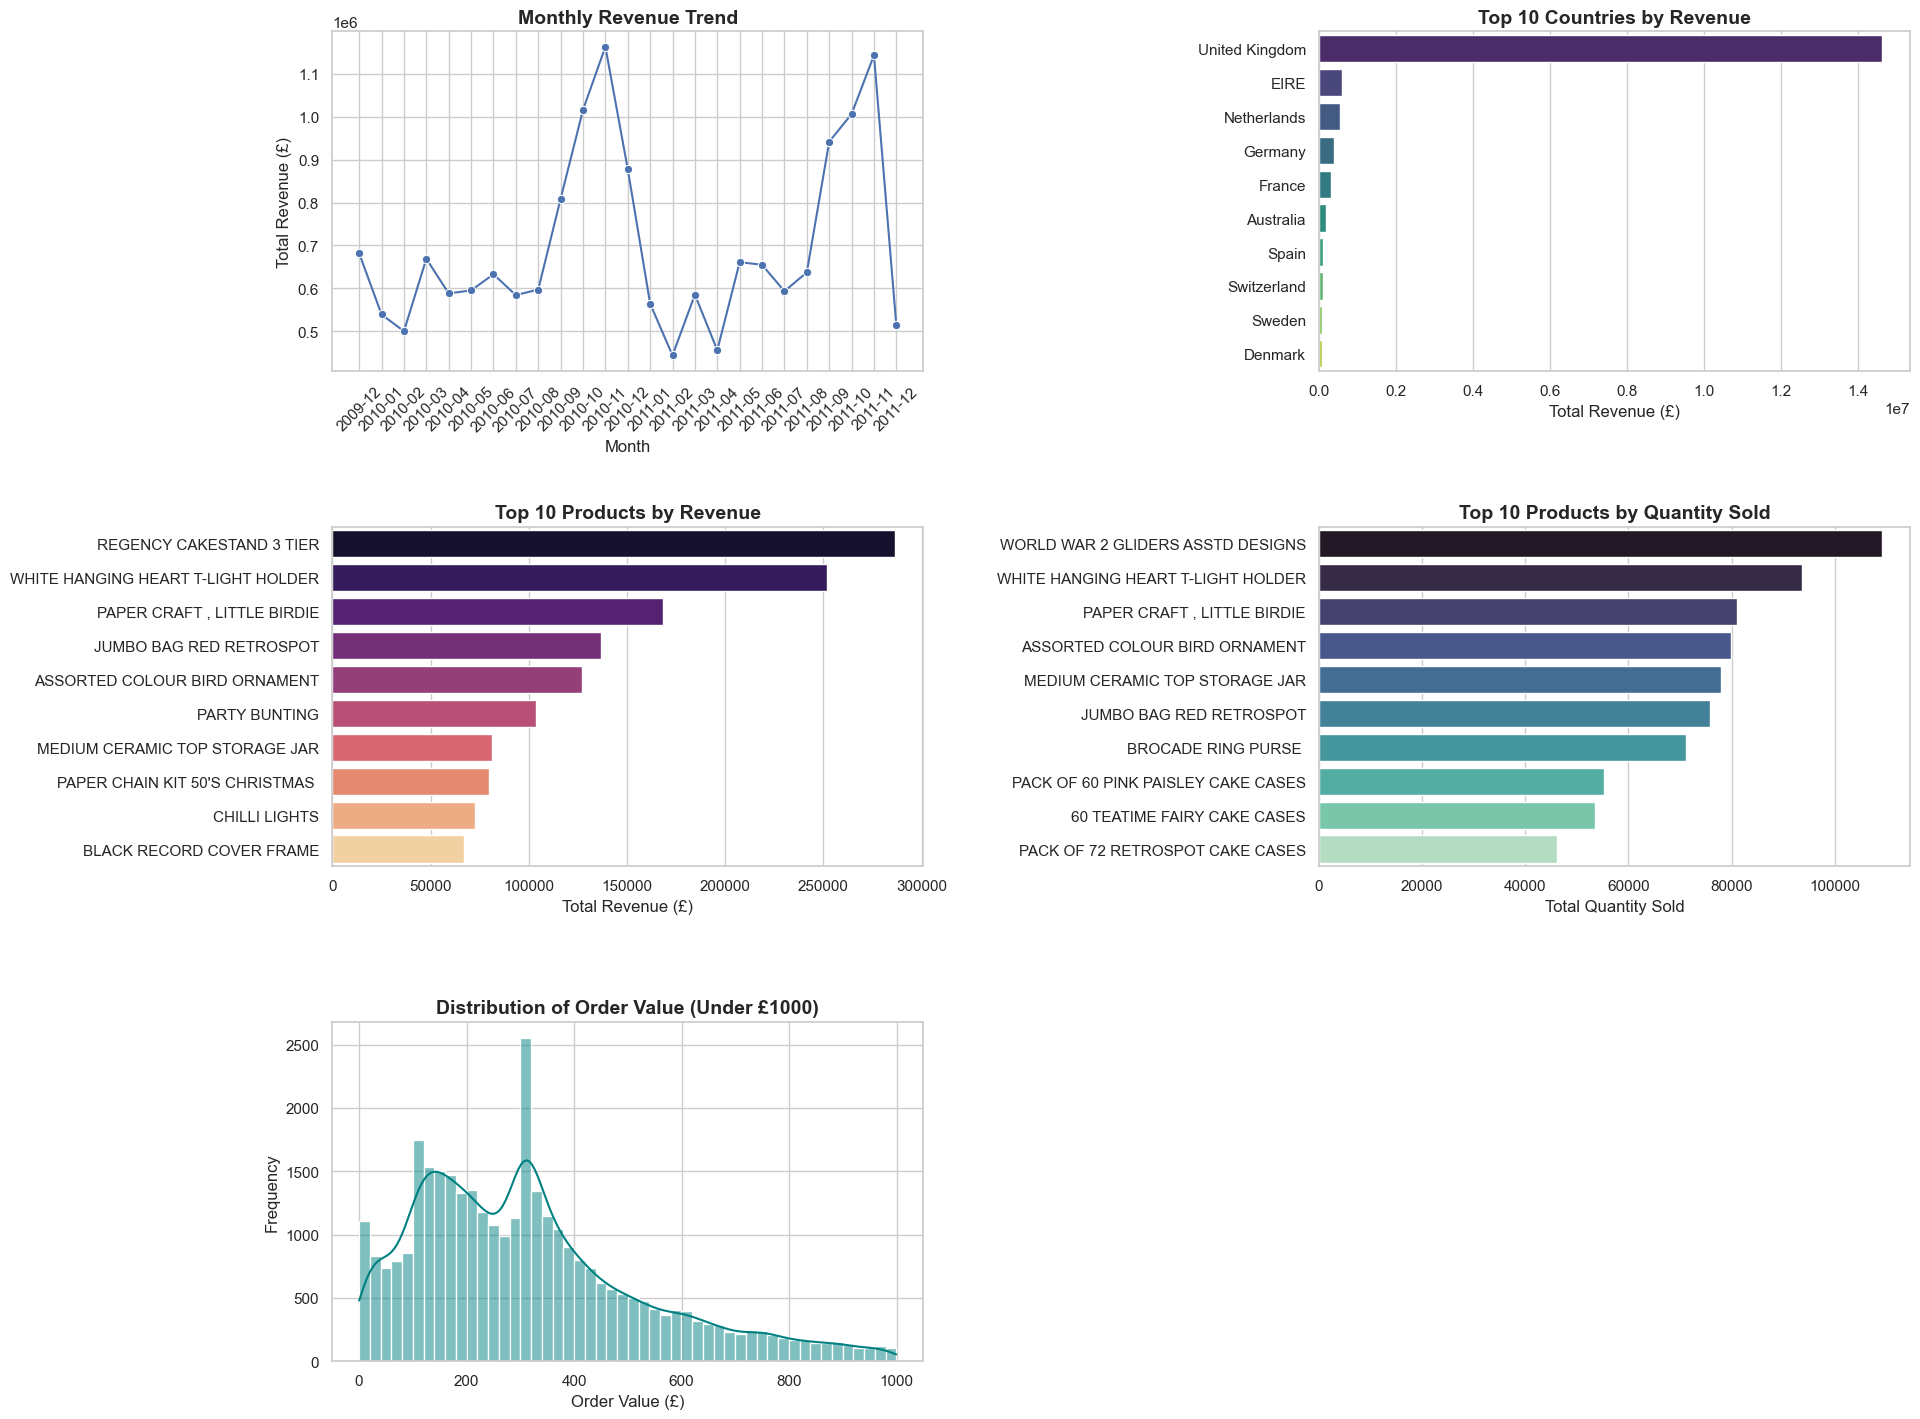

In [5]:

# Set visual style for all plots
sns.set_theme(style="whitegrid")

# 1. Loading the cleaned data
print("Loading cleaned dataset...")
df = pd.read_csv("D:/Retail Pricing & Promotion Analytics/data/processed/cleaned_online_retail.csv")

# Ensure datetime is correctly parsed after loading from CSV
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create a Year-Month column for easier trend plotting
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

plt.figure(figsize=(20, 15))

# --- Chart 1: Revenue trend over time (monthly) ---
plt.subplot(3, 2, 1)
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum().reset_index()
sns.lineplot(data=monthly_revenue, x='YearMonth', y='Revenue', marker='o', color='b')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')

# --- Chart 2: Revenue by country (Top 10 to keep it readable) ---
plt.subplot(3, 2, 2)
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=country_revenue, x='Revenue', y='Country', palette='viridis')
plt.title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('')

# --- Chart 3: Top products by revenue ---
plt.subplot(3, 2, 3)
top_rev_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=top_rev_products, x='Revenue', y='Description', palette='magma')
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('')

# --- Chart 4: Top products by quantity ---
plt.subplot(3, 2, 4)
top_qty_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=top_qty_products, x='Quantity', y='Description', palette='mako')
plt.title('Top 10 Products by Quantity Sold', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('')

# --- Chart 5: Distribution of order value ---
plt.subplot(3, 2, 5)
# Group by InvoiceNo to get the total value per order
order_values = df.groupby('InvoiceNo')['Revenue'].sum()
# Filter out massive outliers just for visualization purposes (e.g., viewing orders under £1000)
sns.histplot(order_values[order_values < 1000], bins=50, kde=True, color='teal')
plt.title('Distribution of Order Value (Under £1000)', fontsize=14, fontweight='bold')
plt.xlabel('Order Value (£)')
plt.ylabel('Frequency')

plt.tight_layout(pad=3.0)
plt.show()